# Experimento: Búsqueda en K-D Tree

Este notebook demuestra cómo funcionan las búsquedas de vecino más cercano usando k-d tree.

## Funciones auxiliares

In [1]:
from FuncionesAux import distancia_km, latlon_a_km, distancia_euclidiana

## 1. Importar Bibliotecas Necesarias

In [2]:
import sys
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import random
import time
import math

# Directorio donde está este notebook / proyecto
PROJECT_DIR = Path.cwd()

# Agregar el proyecto al path de Python
if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

# Configurar visualizaciones
plt.rcParams['figure.figsize'] = (12, 8)

In [3]:
import importlib
import ExperimentoPrim

importlib.reload(ExperimentoPrim)

{1: {4: {'latencia': 2, 'ancho_banda': 100, 'costo': 180}, 5: {'latencia': 3, 'ancho_banda': 100, 'costo': 220}, 6: {'latencia': 2, 'ancho_banda': 100, 'costo': 160}, 7: {'latencia': 3, 'ancho_banda': 80, 'costo': 190}}, 4: {1: {'latencia': 2, 'ancho_banda': 100, 'costo': 180}, 3: {'latencia': 4, 'ancho_banda': 100, 'costo': 200}, 5: {'latencia': 1, 'ancho_banda': 100, 'costo': 80}}, 5: {1: {'latencia': 3, 'ancho_banda': 100, 'costo': 220}, 4: {'latencia': 1, 'ancho_banda': 100, 'costo': 80}, 8: {'latencia': 3, 'ancho_banda': 80, 'costo': 210}}, 6: {1: {'latencia': 2, 'ancho_banda': 100, 'costo': 160}, 7: {'latencia': 1, 'ancho_banda': 100, 'costo': 60}}, 7: {1: {'latencia': 3, 'ancho_banda': 80, 'costo': 190}, 6: {'latencia': 1, 'ancho_banda': 100, 'costo': 60}, 10: {'latencia': 5, 'ancho_banda': 40, 'costo': 100}}, 2: {9: {'latencia': 2, 'ancho_banda': 100, 'costo': 150}, 11: {'latencia': 4, 'ancho_banda': 80, 'costo': 120}, 10: {'latencia': 3, 'ancho_banda': 80, 'costo': 130}}, 9: {

<module 'ExperimentoPrim' from 'c:\\Users\\kimpo\\ITAM\\EDA_py\\Proyecto_Final\\NetOptimizer\\ExperimentoPrim.py'>

## 2. Generar el grafo a partir del csv 

Nos apoyamos de los métodos de ExperimentoPrim.py para crear el grafo y luego graficarlo

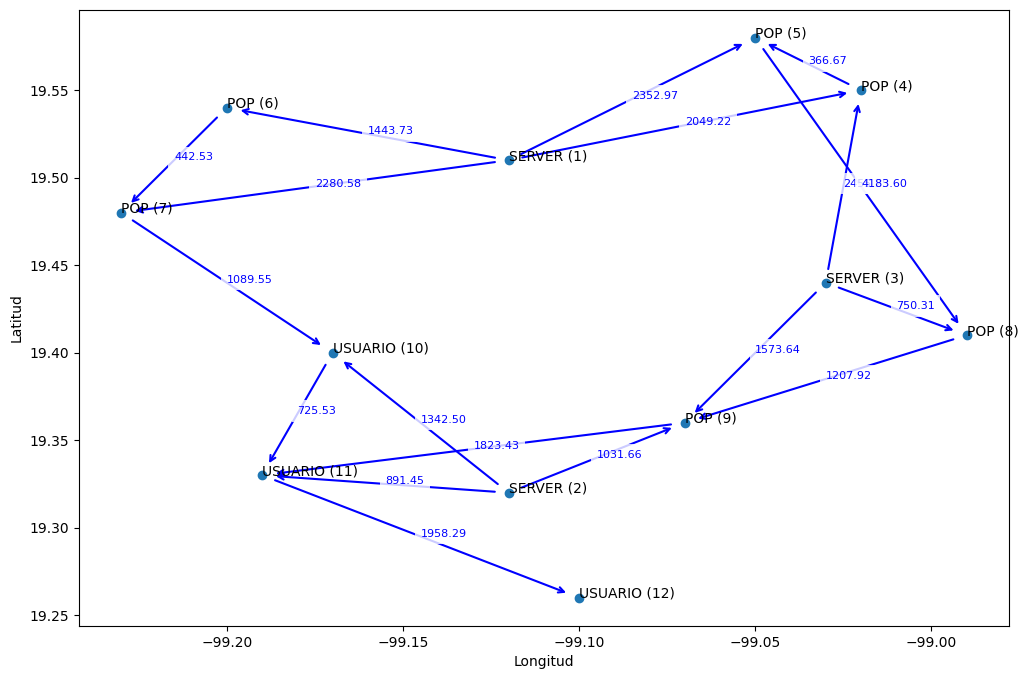

In [4]:
import matplotlib.pyplot as plt
import ExperimentoPrim
import Grafo

grafo = Grafo.Grafo()

x = []
y = []

nodos = ExperimentoPrim.insertaNodos()
grafoC = ExperimentoPrim.insertaElementos(grafo)
conexiones = ExperimentoPrim.conexiones(grafo)
direcciones = ExperimentoPrim.conexiones_con_pos(conexiones)

# NODOS
for tipo, latitud, longitud, id in nodos:

    x.append(longitud)
    y.append(latitud)

    plt.text(
        longitud,
        latitud,
        f"{tipo} ({id})" 
    )

# ARISTAS
for (origen_id, destino_id), (origen, destino) in zip(conexiones, direcciones):

    lat1, lon1 = origen
    lat2, lon2 = destino

    # Flecha dirigida desde origen hacia destino
    plt.annotate(
        "",
        xy=(lon2, lat2),
        xytext=(lon1, lat1),
        arrowprops=dict(
            arrowstyle="->",
            color="blue",
            lw=1.5,
            shrinkA=10,
            shrinkB=10
        ),
        zorder=1
    )

    # Punto medio
    mid_lon = (lon1 + lon2) / 2
    mid_lat = (lat1 + lat2) / 2

    costo_km = grafo.getOrigen()[origen_id][destino_id]["costo"]

    distancia_arista = distancia_km(
        (lat1, lon1),
        (lat2, lon2)
    )

    costo_real = distancia_arista * costo_km

    plt.text(
        mid_lon,
        mid_lat,
        f"{costo_real:.2f}",
        fontsize=8,
        color='blue',
        bbox=dict(
            facecolor='white',
            alpha=0.8,
            edgecolor='none'
        ),
        zorder=7
    )

plt.scatter(x, y)

plt.xlabel("Longitud")
plt.ylabel("Latitud")

plt.show()

## 3. Uso de Prim

Graficamos el árbol de expansión más corto usando latencia como criterio de minimización 

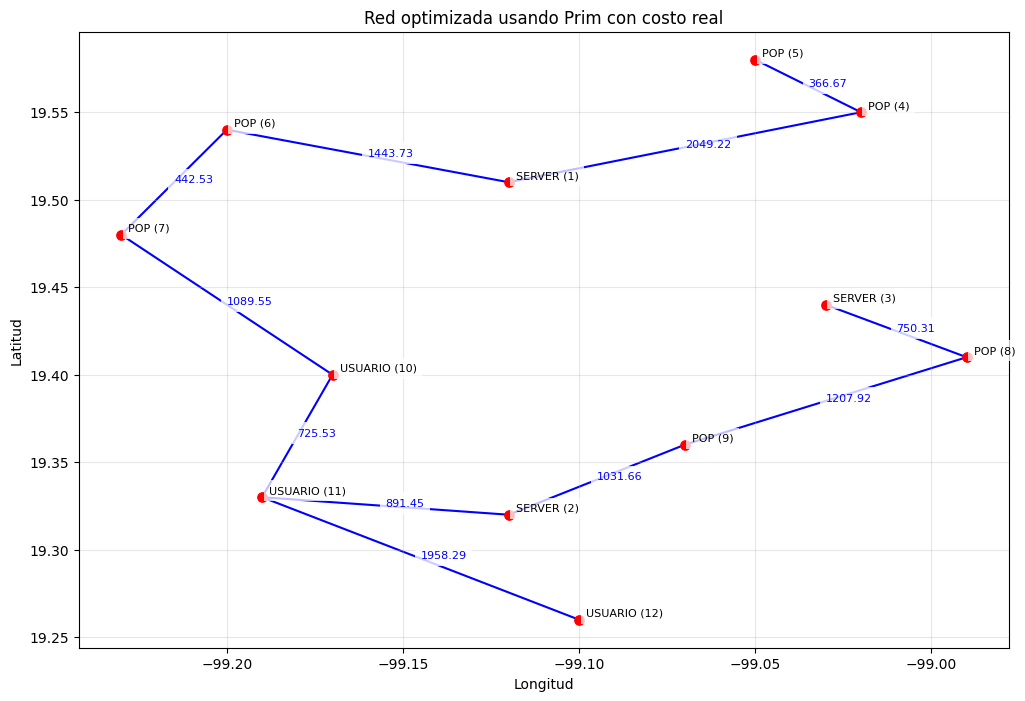

In [5]:

# Guardar posiciones de nodos
posiciones = {}

for tipo, latitud, longitud, id_nodo in nodos:
    posiciones[id_nodo] = (latitud, longitud)


# Obtener MST optimizado por costo real
padre, llave = grafo.prim_costo_real(1, posiciones)

referencias = []

for nodo, padre_nodo in padre.items():
    if padre_nodo is not None:
        referencias.append((padre_nodo, nodo))


direcciones_nodos = ExperimentoPrim.conexiones_con_pos(referencias)


x = []
y = []

# GRAFICAR NODOS Y ETIQUETAS
for tipo, latitud, longitud, id_nodo in nodos:

    x.append(longitud)
    y.append(latitud)

    texto = f"{tipo} ({id_nodo})"

    plt.scatter(
        longitud,
        latitud,
        c='red',
        s=45,
        zorder=5
    )

    plt.text(
        longitud + 0.002,
        latitud + 0.002,
        texto,
        fontsize=8,
        bbox=dict(
            facecolor='white',
            alpha=0.75,
            edgecolor='none'
        ),
        zorder=6
    )

# GRAFICAR ARISTAS Y COSTO REAL
for (origen_id, destino_id), (origen, destino) in zip(referencias, direcciones_nodos):

    lat1, lon1 = origen
    lat2, lon2 = destino

    plt.plot(
        [lon1, lon2],
        [lat1, lat2],
        'b-',
        linewidth=1.5,
        zorder=1
    )

    mid_lon = (lon1 + lon2) / 2
    mid_lat = (lat1 + lat2) / 2

    costo_km = grafo.getOrigen()[origen_id][destino_id]["costo"]

    distancia_arista = distancia_km(
        (lat1, lon1),
        (lat2, lon2)
    )

    costo_real = distancia_arista * costo_km

    plt.text(
        mid_lon,
        mid_lat,
        f"{costo_real:.2f}",
        fontsize=8,
        color='blue',
        bbox=dict(
            facecolor='white',
            alpha=0.8,
            edgecolor='none'
        ),
        zorder=7
    )

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Red optimizada usando Prim con costo real")

plt.grid(alpha=0.3)

plt.show()

## 4. Construir el K-D Tree

El k-d tree organiza los puntos de manera jerárquica para permitir búsquedas eficientes.

In [6]:
# Construir el k-d tree solo con SERVIDORES en coordenadas km
import KD_tree
import math

arbol = KD_tree.kd_tree(2)

# Diccionario para recuperar info del servidor después de la búsqueda
servidores_info = {}

# Puntos que sí entran al KD-tree: servidores convertidos a km
puntos_kd_server = []

for tipo, latitud, longitud, id_nodo in nodos:
    if tipo == "SERVER":
        punto_km = latlon_a_km(latitud, longitud)
        puntos_kd_server.append(punto_km)
        servidores_info[punto_km] = {
            "id": id_nodo,
            "latlon": (latitud, longitud)
        }

# Los siguientes puntos solo son para graficarlos después en lat/lon
puntos_kd_no_server = [
    (latitud, longitud)
    for tipo, latitud, longitud, _ in nodos
    if tipo != "SERVER"
]

puntos_kd_usuario = [
    (latitud, longitud)
    for tipo, latitud, longitud, _ in nodos
    if tipo == "USUARIO"
]

puntos_kd_pop = [
    (latitud, longitud)
    for tipo, latitud, longitud, _ in nodos
    if tipo == "POP"
]

# Crear árbol con servidores en coordenadas km
arbol.creaArbol(puntos_kd_server)

print("Árbol KD construido")
print(f"  Elementos: {arbol.elementos}")
print(f"  Dimensiones: {arbol.dimensiones}")

Árbol KD construido
  Elementos: 3
  Dimensiones: 2


## 4. Realizar Búsquedas de Vecino Más Cercano

Ahora vamos a buscar el punto más cercano a nuestro punto de consulta.

In [7]:
punto_busqueda = (19.53, -99.10)
punto_busqueda = (19.53, -99.02)
punto_busqueda_km = latlon_a_km(*punto_busqueda)

mejorp, mejord = arbol.busca(arbol.raiz, punto_busqueda_km, 0, None, 0)

distancia_km_aprox = math.sqrt(mejord)
info_servidor = servidores_info[mejorp]
lat_server, lon_server = info_servidor["latlon"]

print(f"Nuevo usuario: {punto_busqueda}")
print(f"Servidor más cercano: SERVER ({info_servidor['id']}) en {info_servidor['latlon']}")
print(f"Distancia aproximada: {distancia_km_aprox:.2f} km")

Nuevo usuario: (19.53, -99.02)
Servidor más cercano: SERVER (3) en (19.44, -99.03)
Distancia aproximada: 10.04 km


## 5. Visualizar Resultados

Graficamos los puntos, el punto de búsqueda y su vecino más cercano.

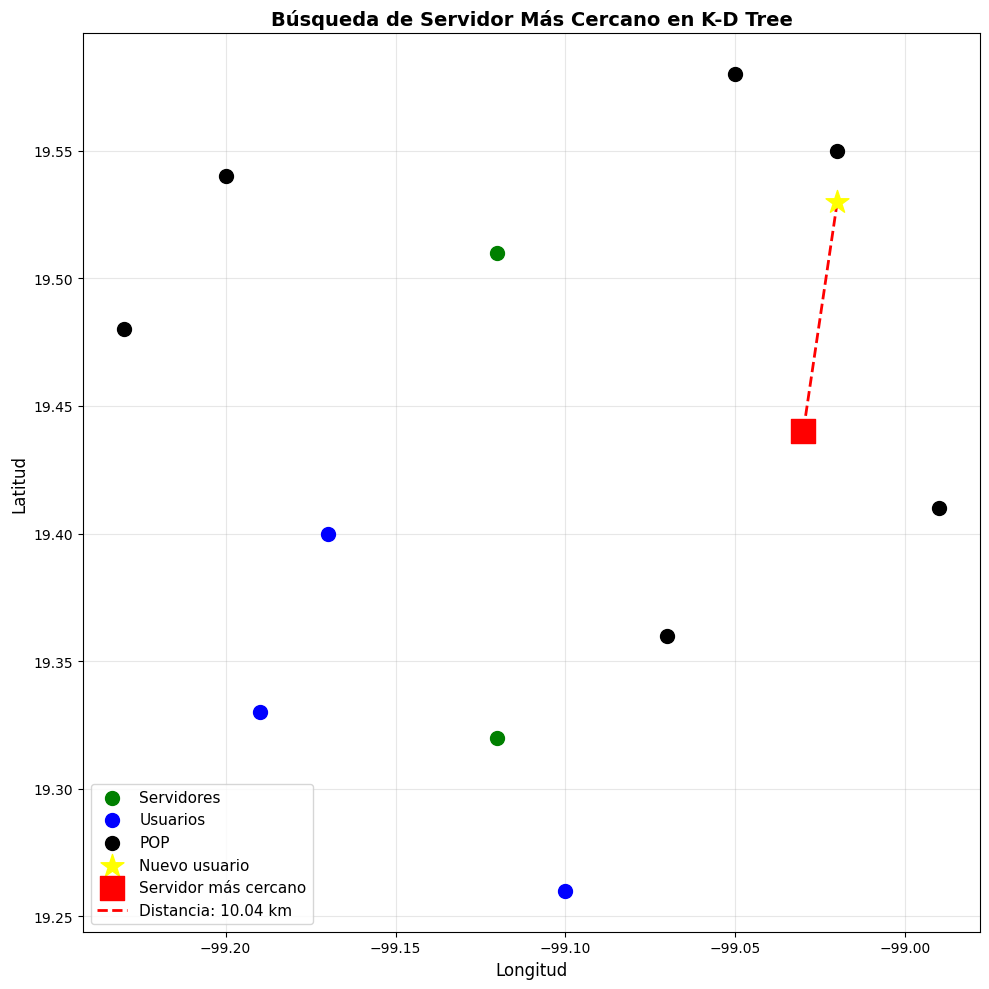

In [8]:
# Visualización
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Separar puntos en lat/lon para graficar
puntos_kd_server_latlon = [info["latlon"] for info in servidores_info.values()]
puntos_kd_usuario = [(latitud, longitud) for tipo, latitud, longitud, _ in nodos if tipo == "USUARIO"]
puntos_kd_pop = [(latitud, longitud) for tipo, latitud, longitud, _ in nodos if tipo == "POP"]
puntos_kd_no_server = [(latitud, longitud) for tipo, latitud, longitud, _ in nodos if tipo != "SERVER"]

# Graficar todos los puntos
xs = [p[1] for p in puntos_kd_server_latlon]
ys = [p[0] for p in puntos_kd_server_latlon]

xn = [p[1] for p in puntos_kd_no_server]
yn = [p[0] for p in puntos_kd_no_server]

xu = [p[1] for p in puntos_kd_usuario]
yu = [p[0] for p in puntos_kd_usuario]

xp = [p[1] for p in puntos_kd_pop]
yp = [p[0] for p in puntos_kd_pop]

ax.scatter(xs, ys, c='green', s=100, label='Servidores', zorder=2)
ax.scatter(xu, yu, c='blue', label='Usuarios', s=100, zorder=2)
ax.scatter(xp, yp, c='black', label='POP', s=100, zorder=2)

# Punto de búsqueda en lat/lon
lat_busqueda, lon_busqueda = punto_busqueda

ax.scatter([lon_busqueda], [lat_busqueda], c='yellow', s=300, marker='*', label='Nuevo usuario', zorder=3)

# Servidor más cercano en lat/lon
info_servidor = servidores_info[mejorp]
lat_server, lon_server = info_servidor["latlon"]

ax.scatter([lon_server], [lat_server], c='red', s=300, marker='s', label='Servidor más cercano', zorder=3)

# Línea entre punto nuevo y servidor más cercano
ax.plot([lon_busqueda, lon_server], [lat_busqueda, lat_server], 'r--', linewidth=2, label=f'Distancia: {distancia_km_aprox:.2f} km')

# Ajustar los ejes al rango real de los datos
todos_lons = xs + xn + [lon_busqueda]
todos_lats = ys + yn + [lat_busqueda]

margen_x = (max(todos_lons) - min(todos_lons)) * 0.05
margen_y = (max(todos_lats) - min(todos_lats)) * 0.05

ax.set_xlim(min(todos_lons) - margen_x, max(todos_lons) + margen_x)
ax.set_ylim(min(todos_lats) - margen_y, max(todos_lats) + margen_y)

ax.set_xlabel('Longitud', fontsize=12)
ax.set_ylabel('Latitud', fontsize=12)
ax.set_title('Búsqueda de Servidor Más Cercano en K-D Tree', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Búsquedas Múltiples

Realicemos varias búsquedas en diferentes puntos.

In [9]:
puntos_consulta = [(19.53, -99.05), (19.30, -99.17), (19.50, -99.19), (19.35, -99.10), (19.45, -99.05)]

print("Múltiples búsquedas:")
print("-" * 60)
print(f"{'Punto buscado':<22} {'Servidor más cercano':<22} {'Distancia km':<15}")
print("-" * 60)

for pc in puntos_consulta:
    pc_km = latlon_a_km(*pc)
    mejorp, mejord = arbol.busca(arbol.raiz, pc_km, 0, None, 0)
    dist = math.sqrt(mejord)
    info_servidor = servidores_info[mejorp]

    pc_redondeado = tuple(round(v, 2) for v in pc)
    server_redondeado = tuple(round(v, 2) for v in info_servidor["latlon"])

    print(f"{str(pc_redondeado):<22} {str(server_redondeado):<22} {dist:<15.2f}")

Múltiples búsquedas:
------------------------------------------------------------
Punto buscado          Servidor más cercano   Distancia km   
------------------------------------------------------------
(19.53, -99.05)        (19.51, -99.12)        7.66           
(19.3, -99.17)         (19.32, -99.12)        5.69           
(19.5, -99.19)         (19.51, -99.12)        7.41           
(19.35, -99.1)         (19.32, -99.12)        3.93           
(19.45, -99.05)        (19.44, -99.03)        2.37           


## 7. Análisis de Rendimiento: K-D Tree vs Búsqueda Lineal

In [10]:
def busqueda_lineal(puntos, punto_busqueda, dimensiones):
    mejorp = None
    mejord = float('inf')
    
    for p in puntos:
        d = sum((p[i] - punto_busqueda[i])**2 for i in range(dimensiones))
        if d < mejord:
            mejord = d
            mejorp = p
    
    return mejorp, mejord


tamaños = [50, 100, 500, 1000, 5000]
resultados = []
dimensiones = 2
repeticiones = 1000

print("\nComparación de Rendimiento")
print("-" * 80)
print(f"{'Tamaño':<15} {'KD-tree (ms)':<20} {'Lineal (ms)':<20} {'Mejora':<10}")
print("-" * 80)

for tamaño in tamaños:
    pts = [tuple(random.randint(0, 1000) for _ in range(dimensiones)) for _ in range(tamaño)]
    pt_busq = (500, 500)

    arb = KD_tree.kd_tree(dimensiones)
    arb.creaArbol(pts)

    inicio = time.perf_counter()
    for _ in range(repeticiones):
        arb.busca(arb.raiz, pt_busq, 0, None, 0)
    tiempo_kd = (time.perf_counter() - inicio) * 1000

    inicio = time.perf_counter()
    for _ in range(repeticiones):
        busqueda_lineal(pts, pt_busq, dimensiones)
    tiempo_lineal = (time.perf_counter() - inicio) * 1000

    mejora = tiempo_lineal / tiempo_kd if tiempo_kd > 0 else float('inf')
    resultados.append((tamaño, tiempo_kd, tiempo_lineal, mejora))

    print(f"{tamaño:<15} {tiempo_kd:<20.2f} {tiempo_lineal:<20.2f} {mejora:.2f}x")

print("-" * 80)


Comparación de Rendimiento
--------------------------------------------------------------------------------
Tamaño          KD-tree (ms)         Lineal (ms)          Mejora    
--------------------------------------------------------------------------------
50              15.45                34.76                2.25x
100             21.52                63.26                2.94x
500             36.75                305.62               8.32x
1000            29.32                635.13               21.66x
5000            26.99                3479.55              128.92x
--------------------------------------------------------------------------------


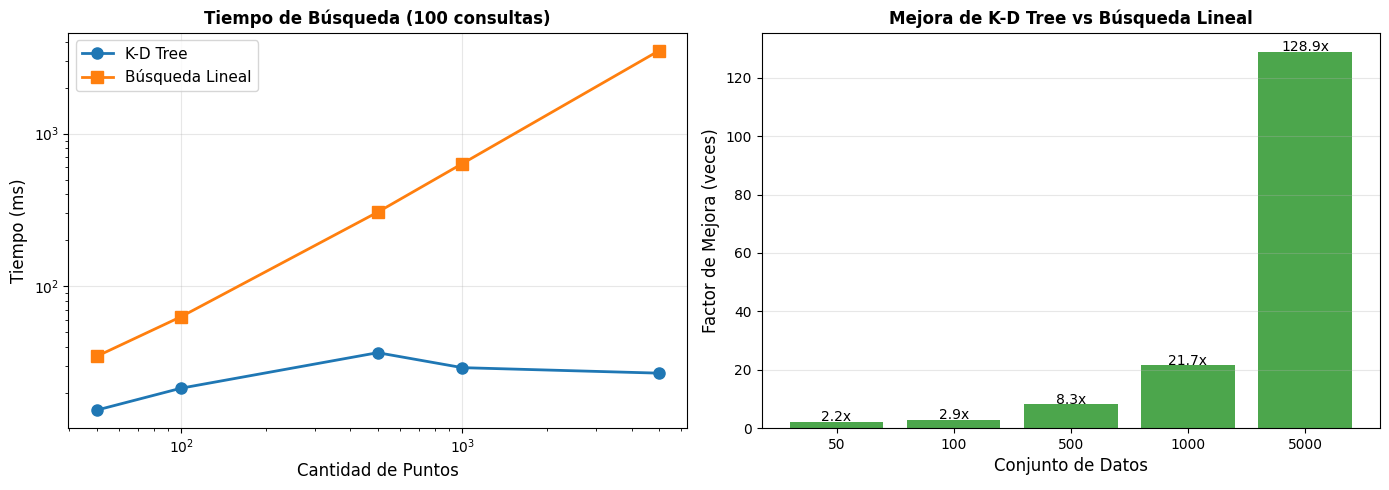

In [11]:
# Graficar comparación de rendimiento
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

tamaños_plot = [r[0] for r in resultados]
kd_times = [r[1] for r in resultados]
lineal_times = [r[2] for r in resultados]
mejoras = [r[3] for r in resultados]

# Gráfico de tiempos
ax1.plot(tamaños_plot, kd_times, 'o-', label='K-D Tree', linewidth=2, markersize=8)
ax1.plot(tamaños_plot, lineal_times, 's-', label='Búsqueda Lineal', linewidth=2, markersize=8)
ax1.set_xlabel('Cantidad de Puntos', fontsize=12)
ax1.set_ylabel('Tiempo (ms)', fontsize=12)
ax1.set_title('Tiempo de Búsqueda (100 consultas)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xscale('log')
ax1.set_yscale('log')

# Gráfico de mejora
ax2.bar(range(len(tamaños_plot)), mejoras, color='green', alpha=0.7)
ax2.set_xlabel('Conjunto de Datos', fontsize=12)
ax2.set_ylabel('Factor de Mejora (veces)', fontsize=12)
ax2.set_title('Mejora de K-D Tree vs Búsqueda Lineal', fontsize=12, fontweight='bold')
ax2.set_xticks(range(len(tamaños_plot)))
ax2.set_xticklabels(tamaños_plot)
ax2.grid(True, alpha=0.3, axis='y')

# Agregar valores en las barras
for i, v in enumerate(mejoras):
    ax2.text(i, v + 0.1, f'{v:.1f}x', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## EXTRA: Ahora vamos a medir la ruta más óptima considerando todos los factores
Para esto vamos a buscar maximizar el ancho de banda, minimizar la latencia y minimizar el costo. 
La manera de hacerlo va a ser pensando la distancia de una manera distinta, en vez de direcciones vamos a considerar la distancia de un nodo a otro como dis = Δ (1/ ancho de banda) ^2 +  Δ latencia ^2 + Δ costo ^ 2

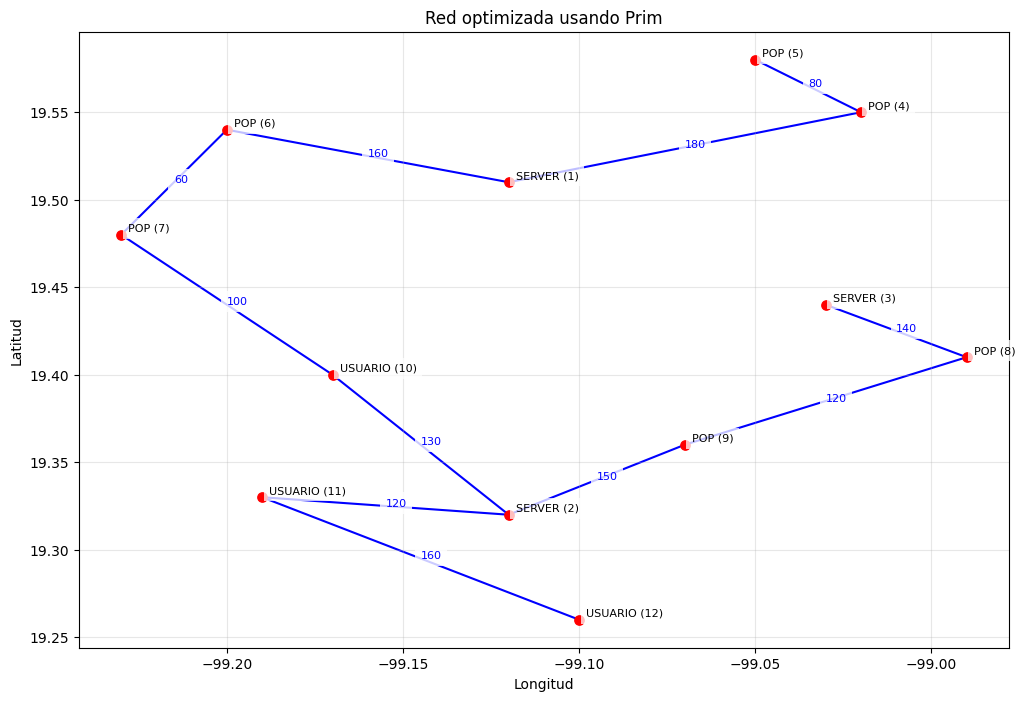

In [12]:
grafo.precalcular_pesos_combinados()
referencias = ExperimentoPrim.referencias_despues_prim_combinado(grafo) # Con este método llamamos al prim con 1 y generamos las referencias
direcciones_nodos = ExperimentoPrim.conexiones_con_pos(referencias)


# Guardar posiciones de nodos
x = []
y = []

# GRAFICAR NODOS Y ETIQUETAS
for tipo, latitud, longitud, id_nodo in nodos:

    x.append(longitud)
    y.append(latitud)

    # Texto del nodo
    texto = f"{tipo} ({id_nodo})"

    # Nodo
    plt.scatter(
        longitud,
        latitud,
        c='red',
        s=45,
        zorder=5
    )

    # Etiqueta del nodo
    plt.text(
        longitud + 0.002,
        latitud + 0.002,
        texto,
        fontsize=8,
        bbox=dict(
            facecolor='white',
            alpha=0.75,
            edgecolor='none'
        ),
        zorder=6
    )

# GRAFICAR ARISTAS Y LATENCIAS
for (origen_id, destino_id), (origen, destino) in zip(referencias, direcciones_nodos):

    # Coordenadas origen/destino
    lat1, lon1 = origen
    lat2, lon2 = destino

    # Dibujar línea
    plt.plot(
        [lon1, lon2],
        [lat1, lat2],
        'b-',
        linewidth=1.5,
        zorder=1
    )

    # Calcular punto medio
    mid_lon = (lon1 + lon2) / 2
    mid_lat = (lat1 + lat2) / 2

    # Obtener latencia desde el grafo
    costo_km = grafo.getOrigen()[origen_id][destino_id]["costo"]

    # Mostrar latencia en medio de la línea
    plt.text(
        mid_lon,
        mid_lat,
        str(costo_km),
        fontsize=8,
        color='blue',
        bbox=dict(
            facecolor='white',
            alpha=0.8,
            edgecolor='none'
        ),
        zorder=7
    )

# Títulos
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Red optimizada usando Prim")

# Cuadrícula
plt.grid(alpha=0.3)

# Mostrar resultado
plt.show()


## 8. Optimización de latencias para cada usuario con Dijkstra

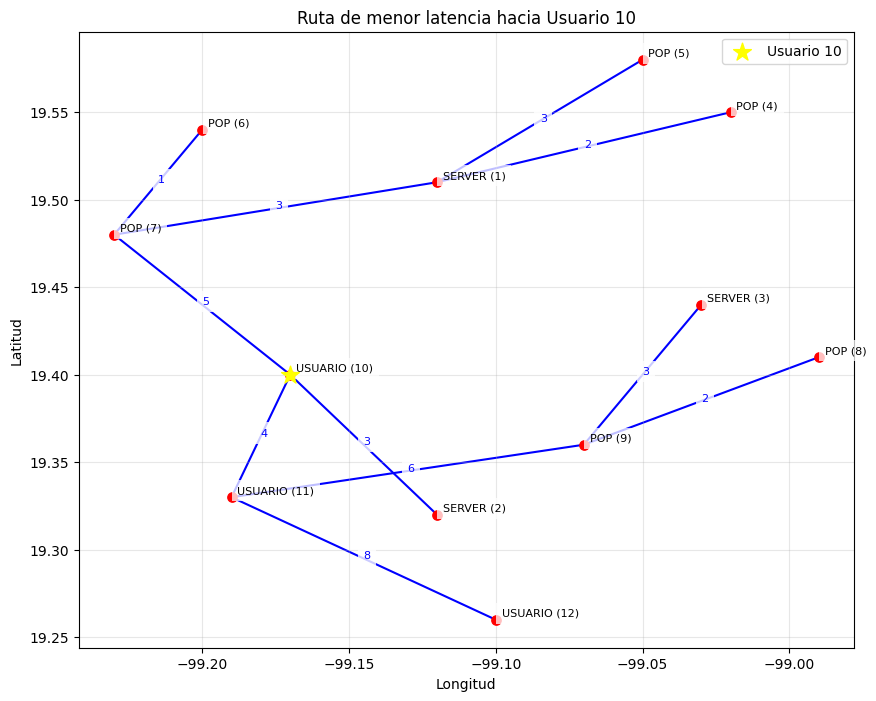

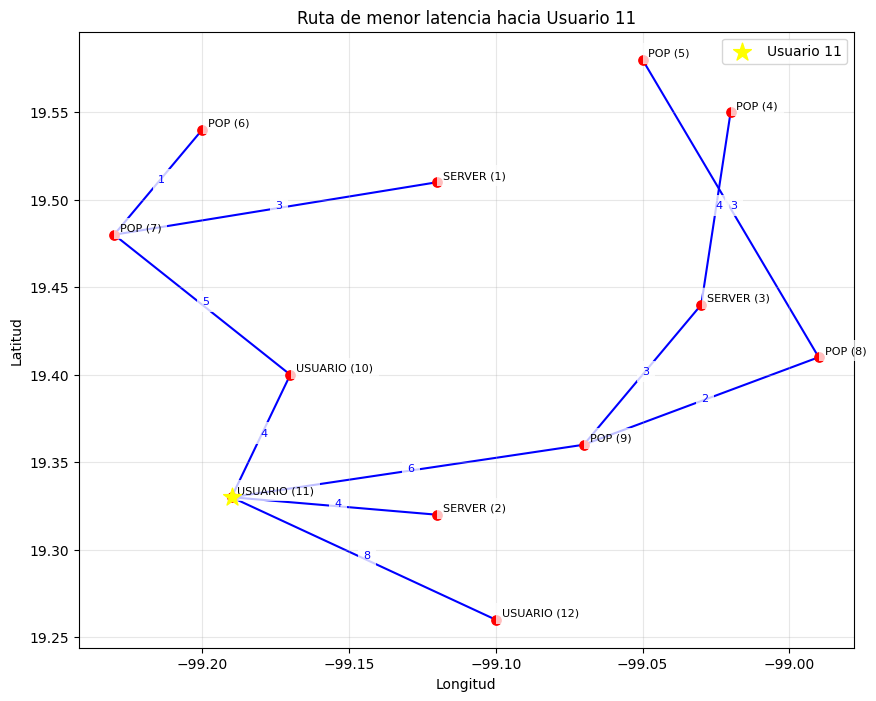

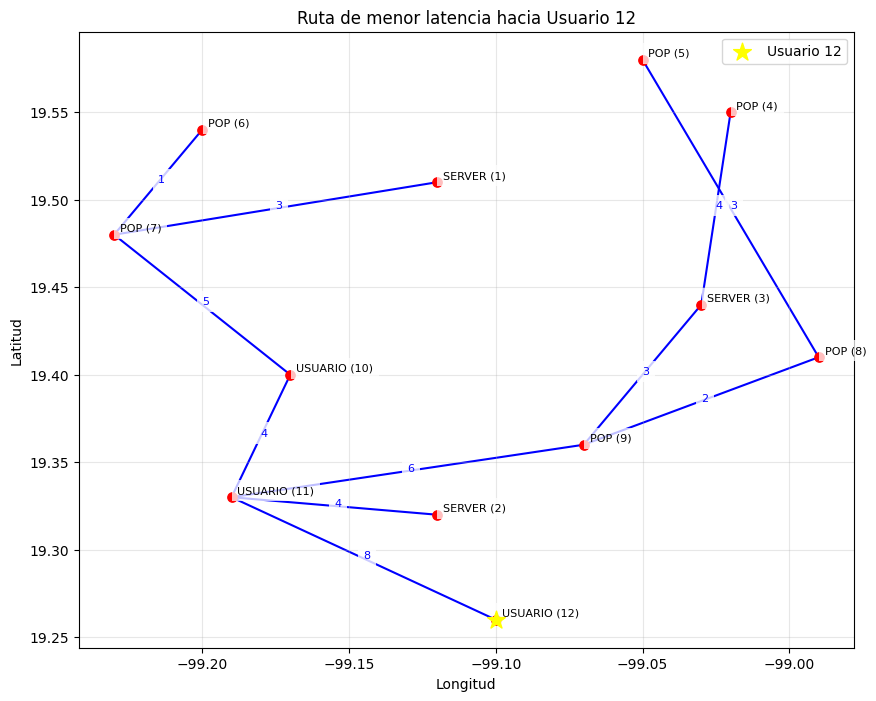

In [13]:
import matplotlib.pyplot as plt
import ExperimentoDijkstra
import ExperimentoPrim
import Grafo

grafo = Grafo.Grafo()
grafo = ExperimentoPrim.insertaElementos(grafo)
nodos = ExperimentoPrim.insertaNodos()

referencias = []
direcciones = []
usuarios = [nodo for nodo in nodos if nodo[0] == "USUARIO"]

# Obtener rutas generadas por Dijkstra
for i in [10, 11, 12]:
    ref = ExperimentoDijkstra.referencias_despues_Dijkstra(grafo, i)
    referencias.append(ref)
    direcciones.append(ExperimentoPrim.conexiones_con_pos(ref))

# Graficar una red por cada usuario
for i, (usuario, referencia, direcciones_nodos) in enumerate(zip(usuarios, referencias, direcciones)):

    plt.figure(figsize=(10, 8))

    # Graficar nodos
    for tipo, latitud, longitud, id_nodo in nodos:
        plt.scatter(longitud, latitud, c='red', s=45, zorder=5)
        plt.text(longitud + 0.002, latitud + 0.002, f"{tipo} ({id_nodo})", fontsize=8,
                 bbox=dict(facecolor='white', alpha=0.75, edgecolor='none'), zorder=6)

    # Graficar aristas de la ruta
    for (origen_id, destino_id), (origen, destino) in zip(referencia, direcciones_nodos):
        lat1, lon1 = origen
        lat2, lon2 = destino

        plt.plot([lon1, lon2], [lat1, lat2], 'b-', linewidth=1.5, zorder=1)

        mid_lon = (lon1 + lon2) / 2
        mid_lat = (lat1 + lat2) / 2

        latencia = grafo.getOrigen()[origen_id][destino_id]["latencia"]

        plt.text(mid_lon, mid_lat, str(round(latencia, 2)), fontsize=8, color='blue',
                 bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'), zorder=7)

    tipo_usuario, lat_usuario, lon_usuario, id_usuario = usuario

    plt.scatter(lon_usuario, lat_usuario, c='yellow', s=180, marker='*', zorder=8, label=f"Usuario {id_usuario}")
    plt.xlabel("Longitud")
    plt.ylabel("Latitud")
    plt.title(f"Ruta de menor latencia hacia Usuario {id_usuario}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

## 9. Estructura Extra: MaxHeap para el mayor ancho de banda

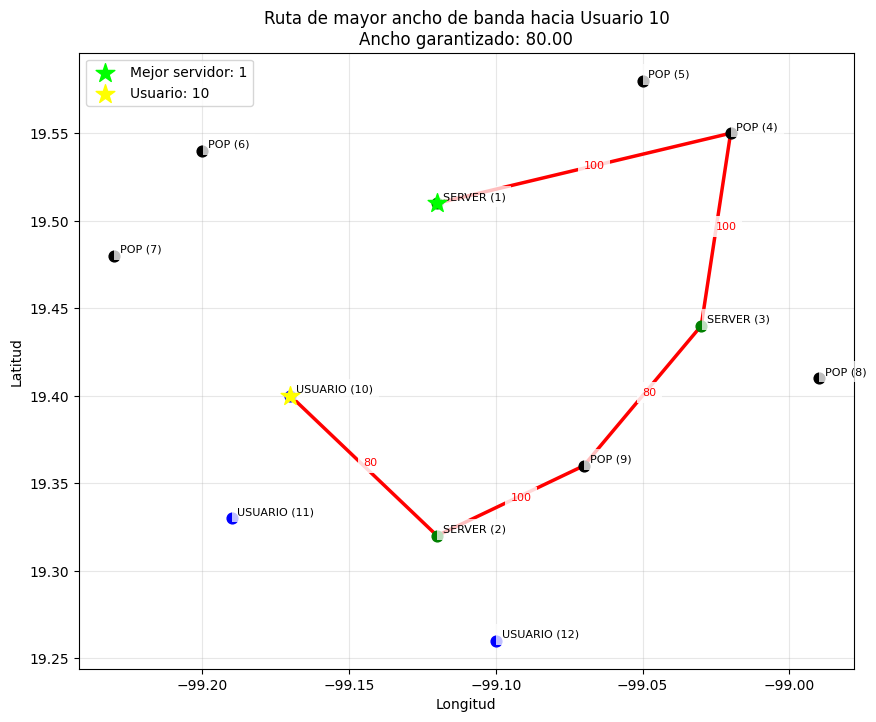

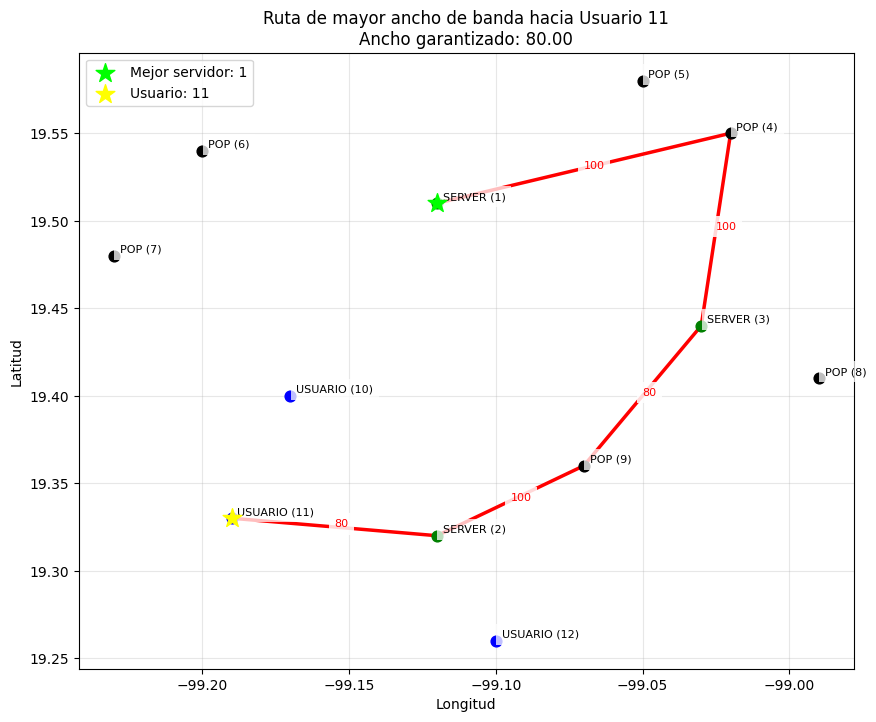

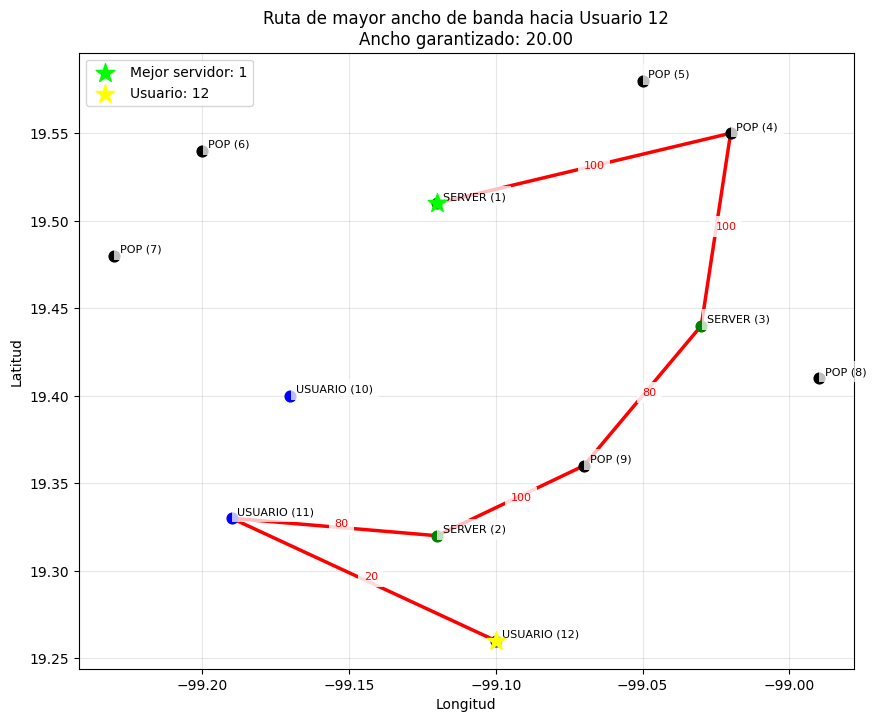

In [14]:
import matplotlib.pyplot as plt
import ExperimentoPrim
import Grafo
import numpy as np

grafo = Grafo.Grafo()
grafo = ExperimentoPrim.insertaElementos(grafo)
nodos = ExperimentoPrim.insertaNodos()

servidores = [id_nodo for tipo, lat, lon, id_nodo in nodos if tipo == "SERVER"]
usuarios = [id_nodo for tipo, lat, lon, id_nodo in nodos if tipo == "USUARIO"]
posiciones = {id_nodo: (lat, lon) for tipo, lat, lon, id_nodo in nodos}

def reconstruir_ruta(padre, destino):
    ruta = []
    actual = destino
    while actual is not None:
        ruta.append(actual)
        actual = padre[actual]
    return ruta[::-1]

def ruta_a_referencias(ruta):
    return [(ruta[i], ruta[i + 1]) for i in range(len(ruta) - 1)]

for usuario in usuarios:
    mejor_servidor = None
    mejor_ancho = -np.inf
    mejor_ruta = None

    for servidor in servidores:
        padre, ancho = grafo.dijkstra_max_ancho_banda(servidor)

        if ancho[usuario] > mejor_ancho:
            mejor_ancho = ancho[usuario]
            mejor_servidor = servidor
            mejor_ruta = reconstruir_ruta(padre, usuario)

    referencias = ruta_a_referencias(mejor_ruta)
    direcciones_nodos = ExperimentoPrim.conexiones_con_pos(referencias)

    plt.figure(figsize=(10, 8))

    # Graficar nodos
    for tipo, latitud, longitud, id_nodo in nodos:
        color = "green" if tipo == "SERVER" else "blue" if tipo == "USUARIO" else "black"
        plt.scatter(longitud, latitud, c=color, s=60, zorder=5)
        plt.text(longitud + 0.002, latitud + 0.002, f"{tipo} ({id_nodo})", fontsize=8,
                 bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"), zorder=6)

    # Graficar ruta de mayor ancho de banda
    for (origen_id, destino_id), (origen, destino) in zip(referencias, direcciones_nodos):
        lat1, lon1 = origen
        lat2, lon2 = destino

        plt.plot([lon1, lon2], [lat1, lat2], "r-", linewidth=2.5, zorder=2)

        mid_lon = (lon1 + lon2) / 2
        mid_lat = (lat1 + lat2) / 2
        ancho_arista = grafo.getOrigen()[origen_id][destino_id]["ancho_banda"]

        plt.text(mid_lon, mid_lat, str(round(ancho_arista, 2)), fontsize=8, color="red",
                 bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"), zorder=7)

    lat_s, lon_s = posiciones[mejor_servidor]
    lat_u, lon_u = posiciones[usuario]

    plt.scatter(lon_s, lat_s, c="lime", s=200, marker="*", label=f"Mejor servidor: {mejor_servidor}", zorder=8)
    plt.scatter(lon_u, lat_u, c="yellow", s=200, marker="*", label=f"Usuario: {usuario}", zorder=8)

    plt.xlabel("Longitud")
    plt.ylabel("Latitud")
    plt.title(f"Ruta de mayor ancho de banda hacia Usuario {usuario}\nAncho garantizado: {mejor_ancho:.2f}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()